In [1]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

import os, sys
from scipy import optimize
sys.path.append(os.path.abspath('../../Software/.'))
import rate_methods_library as RM
import ks_censored as ksc

In [2]:
beta = 1. / (312.*8.314e-3)
print(f'kt: {1/beta}, beta: {beta}')

kt: 2.5939680000000003, beta: 0.38550976727546366


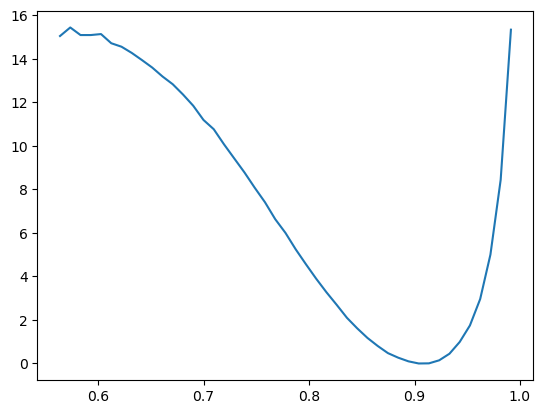

In [3]:
fes_Q = np.loadtxt('../../Data/protG/PMF/pmf_Q.dat')
xi = 55
plt.plot(fes_Q[xi:,0],(fes_Q[xi:,1]-np.min(fes_Q[xi:,1])))

barr4: ln <e^βV> = 1.3113862397160405
barr5: ln <e^βV> = 1.6217468948547606
barr6: ln <e^βV> = 1.9226527042012092
barr7: ln <e^βV> = 2.2126252537686306
barr8: ln <e^βV> = 2.4901023721488897
barr10: ln <e^βV> = 3.0013823782973734


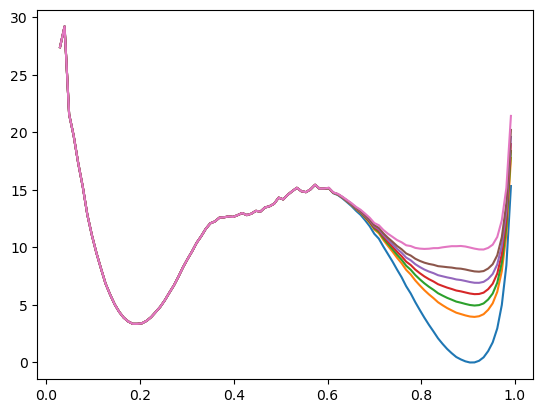

In [4]:
fes_Q = np.loadtxt('../../Data/protG/PMF/pmf_Q.dat')
plt.plot(fes_Q[:,0],(fes_Q[:,1]-np.min(fes_Q[:,1])))

barrs = [4,5,6,7,8,10]
gaussian = lambda x, H: H*np.exp(-((x-0.9)**2)/(0.13**2))
gaussianQ = lambda x, H: H*np.exp(-((x-0.9)**2)/(0.13**2))
for barr in barrs:
    plt.plot(fes_Q[:,0], (fes_Q[:,1]-np.min(fes_Q[:,1]))+gaussian(fes_Q[:,0],barr))
    print(f'barr{barr}: ln <e^βV> = {np.log( np.average(np.exp(beta*gaussian(fes_Q[55:,0],barr)),weights=np.exp(-beta*(gaussian(fes_Q[55:,0],barr)+(fes_Q[55:,1]-np.min(fes_Q[55:,1]))))) )}')

In [5]:
k0s_q = {}
k0s_q2 = {}
v_datas_q = {}
avg_ebv_q = []
ana_avg_ebv_q = []
avg_ebv_t_q = {}

gammas = np.linspace(0,1,21)
barrs = ['4','5','6','7','8','10']

ts_barrs = []
ix_col_barrs_q = []
ys_barrs = []
emp_rates_q = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}

def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_q[barr] = []
    k0s_q2[barr] = []
    
    colvars = glob(f"../../Data/protG/Q_frac_native_contacts_gaussian/qruns_{barr}kJ/*/bias.colvar")
    log_files = glob(f"../../Data/protG/Q_frac_native_contacts_gaussian/qruns_{barr}kJ/*/p.log")
    data = RM.get_data(colvars,0,5,time_scale_factor=1e-6)
    num_runs = len(data)
    colvars_numbers = np.array([colvar.split('/')[-2].split('_')[-1] for colvar in colvars])
    logs_numbers = np.array([log_file.split('/')[-2].split('_')[-1] for log_file in log_files])
    #for i, traj in enumerate(data):
    #    if (len(traj) < 199999):
    #        print(i+1, len(traj))
    
    runs = [f"{i+1}" for i in range(num_runs)]

    # Handle transitions and killed simulations
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    event_notend = RM.get_event(data, maxlen=100000, quiet=True)
    killed = np.logical_xor(transitioned, event_notend)
    nontransition = np.logical_not(event_notend)
    #print(f'transitioned: {colvars_numbers[np.nonzero(transitioned)[0]]}')
    #print(f'killed: {colvars_numbers[np.nonzero(killed)[0]]}')
    #print(f'ended: {colvars_numbers[np.nonzero(nontransition)[0]]}')
    final_times = np.array([traj[-1][0] for traj in data])
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_maxrow_count = max(len(traj[:,0]) for traj in data)
    v_data = np.full((len(data), colvar_maxrow_count), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:len(traj)] = traj[:,1]
    v_datas_q[barr] = v_data
    
    ecdfxs[barr] = np.sort(final_times)[:transitioned.sum()] # This is only valid if all transitions occur before all non-transitioned simulations ended.
    ecdfys[barr] = np.linspace(1/num_runs,1,num_runs)[:transitioned.sum()]
    emp_rate = optimize.curve_fit(poisson_CDF,ecdfxs[barr],ecdfys[barr],p0=1e-6)[0][0]
    emp_rates_q[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')

    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    ecdfxs[barr] = t
    ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_q[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln <e^βV>: {np.log(avg)}')
    print(f'Analytical ln <e^βV>: {np.log( np.average(np.exp(beta*gaussianQ(fes_Q[55:,0],np.float64(barr))),weights=np.exp(-beta*(gaussianQ(fes_Q[55:,0],np.float64(barr))+(fes_Q[55:,1]-np.min(fes_Q[55:,1]))))) )}')
    avg_ebv_q.append(np.log(avg))
    ana_avg_ebv_q.append(np.log( np.average(np.exp(beta*gaussianQ(fes_Q[55:,0],np.float64(barr))),weights=np.exp(-beta*(gaussianQ(fes_Q[55:,0],np.float64(barr))+(fes_Q[55:,1]-np.min(fes_Q[55:,1]))))) ))
    
    print('')
    
    for gamma in gammas:
        #avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=1))
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=0))
        avg2 = np.average(np.exp(beta*gamma*gaussianQ(fes_Q[55:,0],np.float64(barr))),weights=np.exp(-beta*(gaussianQ(fes_Q[55:,0],np.float64(barr))+(fes_Q[55:,1]-np.min(fes_Q[55:,1])))))
        k0s_q[barr].append(np.log(emp_rate)-np.log(avg))
        k0s_q2[barr].append(np.log(emp_rate)-np.log(avg2))
        
        #print(gamma)

100 out of 100 simulations transitioned.
avg. max. bias: 3.9998179300000003
tau_obs: 0.18528105095253838, k_obs: 5.397206000608017, log k_obs: 1.685881412374073
Modified KS stat: 0.5754991139371707; p = 0.8949683776949791
ln <e^βV>: 1.3117523994526619
Analytical ln <e^βV>: 1.3113862397160405

100 out of 100 simulations transitioned.
avg. max. bias: 4.99998534
tau_obs: 0.15805400303192604, k_obs: 6.3269514268360885, log k_obs: 1.8448185130112205
Modified KS stat: 0.8398193493979182; p = 0.4809142902575416
ln <e^βV>: 1.6415147173514815
Analytical ln <e^βV>: 1.6217468948547606

100 out of 100 simulations transitioned.
avg. max. bias: 5.997999109999999
tau_obs: 0.09925908206256341, k_obs: 10.074644850832852, log k_obs: 2.3100218566737496
Modified KS stat: 0.8879875730914948; p = 0.40952844447592174
ln <e^βV>: 1.9324463332984865
Analytical ln <e^βV>: 1.9226527042012092

100 out of 100 simulations transitioned.
avg. max. bias: 6.99872198
tau_obs: 0.07126772836330153, k_obs: 14.03159638963514

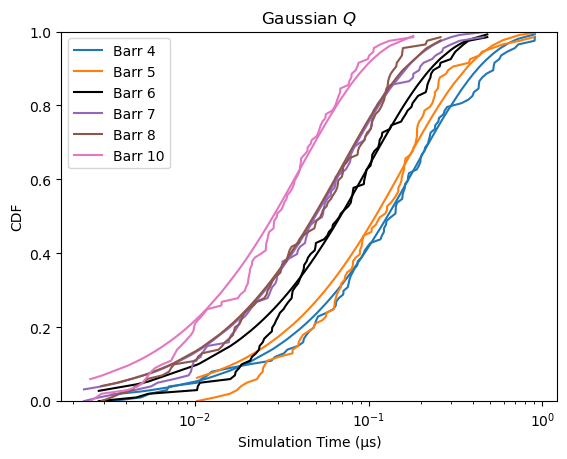

In [6]:
plt.xscale('log')
plt.ylim((0,1))

colors = ['C0','C1','k','C4','C5','C6','C7','C8','C9','C10']

for i, barr in enumerate(barrs):
    plt.plot(ecdfxs[barr],ecdfys[barr],label=f'Barr {barr}',color=colors[i])
    plt.plot(ecdfxs[barr],poisson_CDF(ecdfxs[barr],emp_rates_q[barr]),color=colors[i])

plt.title(r'Gaussian $Q$')
plt.xlabel('Simulation Time (μs)')
plt.ylabel('CDF')
plt.legend()

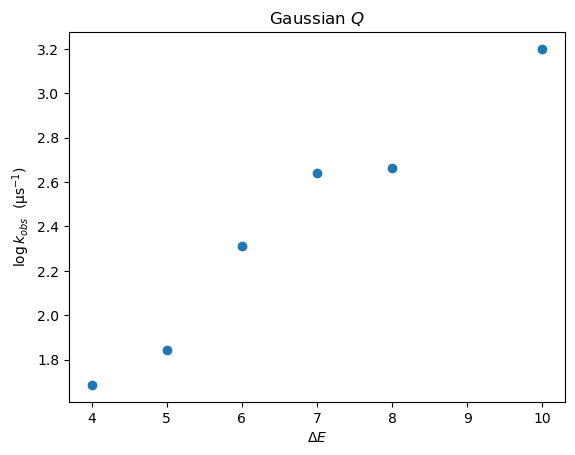

In [7]:
plt.title(r'Gaussian $Q$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{μs}^{-1})$')
plt.xlabel(r'$\Delta E$')
plt.scatter([float(barr) for barr in barrs],[k0s_q[barr][0] for barr in barrs])

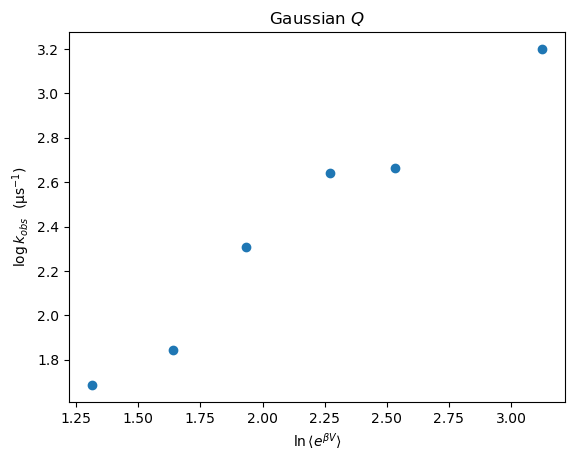

In [8]:
plt.title(r'Gaussian $Q$')
plt.xlabel(r'$\ln \langle e^{\beta V} \rangle$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{μs}^{-1})$')
plt.scatter(avg_ebv_q,[k0s_q[barr][0] for barr in barrs])

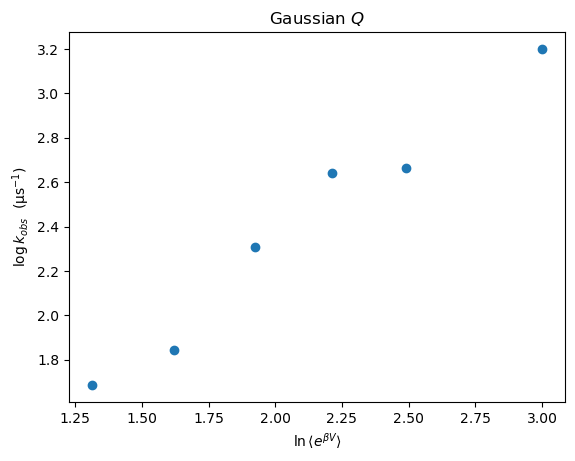

In [9]:
plt.title(r'Gaussian $Q$')
plt.xlabel(r'$\ln \langle e^{\beta V} \rangle$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{μs}^{-1})$')
plt.scatter(ana_avg_ebv_q,[k0s_q2[barr][0] for barr in barrs])

Text(0, 0.5, '$\\ln k_0~~(\\mathrm{μs}^{-1})$')

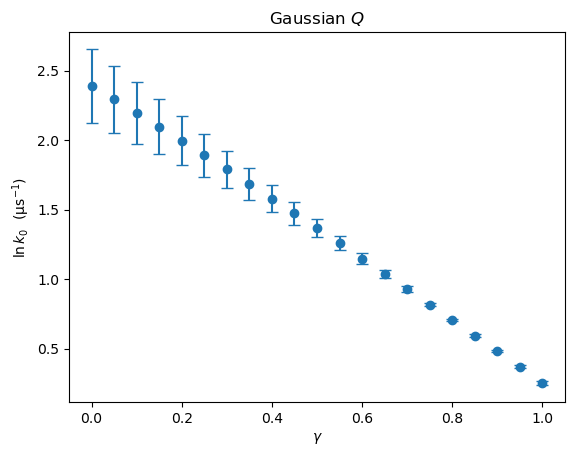

In [10]:
avgs_q = [np.mean([k0s_q[barr][i] for barr in barrs]) for i in range(len(gammas))]
vars_q = [np.var([k0s_q[barr][i] for barr in barrs]) for i in range(len(gammas))]

plt.errorbar(gammas,avgs_q,yerr=vars_q,linestyle='',marker='o',capsize=4)
#plt.axhline(np.log(true),linestyle='--',color='k',label=r'$\ln k_0$')
plt.title(r'Gaussian $Q$')
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\ln k_0~~(\mathrm{μs}^{-1})$')

Text(0, 0.5, 'Variance')

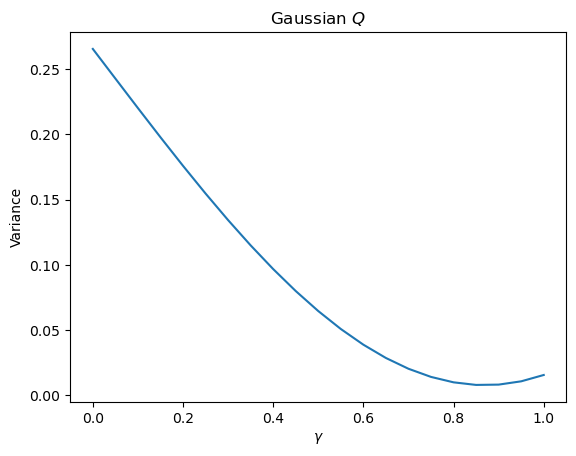

In [11]:
plt.plot(gammas,vars_q)
plt.title(r'Gaussian $Q$')
plt.xlabel(r'$\gamma$')
plt.ylabel('Variance')

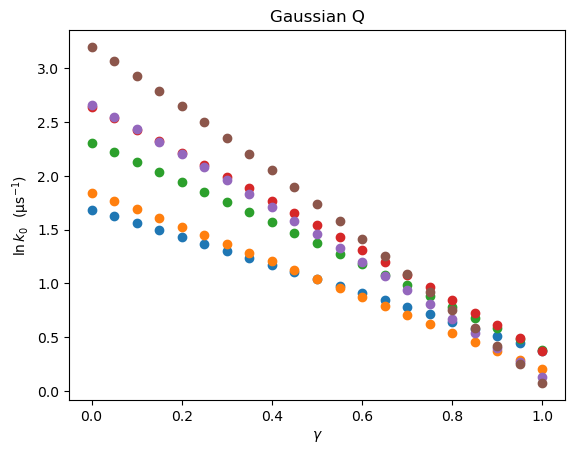

In [12]:
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\ln k_0~~(\mathrm{μs}^{-1})$')
plt.title(r'Gaussian Q')

for barr in barrs:
    plt.scatter(gammas,k0s_q[barr])


In [13]:
def variance(gamma):
    k0s = []
    for barr in barrs:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_datas_q[barr]),axis=0))
        k0s.append(np.log(emp_rates_q[barr])-np.log(avg))
    return np.var(k0s)

gamma_best_q = optimize.minimize_scalar(variance,bounds=(0.,1.)).x
k0s = []
for barr in barrs:
    avg = np.mean(np.nanmean(np.exp(beta*gamma_best_q*v_datas_q[barr]),axis=0))
    k0s.append(np.log(emp_rates_q[barr])-np.log(avg))
k0_best_q = np.mean(k0s)
print(f'LEAST VAR:  gamma: {gamma_best_q}, k0: {np.exp(k0_best_q)} μs^-1, τ0: {np.exp(-k0_best_q)} μs')

LEAST VAR:  gamma: 0.8697636696032494, k0: 1.732608363292869 μs^-1, τ0: 0.5771644770890249 μs


In [14]:
def variance(gamma):
    k0s = []
    for barr in barrs:
        avg = np.average(np.exp(beta*gamma*gaussianQ(fes_Q[55:,0],np.float64(barr))),weights=np.exp(-beta*(gaussianQ(fes_Q[55:,0],np.float64(barr))+(fes_Q[55:,1]-np.min(fes_Q[55:,1])))))
        k0s.append(np.log(emp_rates_q[barr])-np.log(avg))
    return np.var(k0s)

gamma_best_q2 = optimize.minimize_scalar(variance,bounds=(0.,1.)).x
k0s = []
for barr in barrs:
    avg = np.average(np.exp(beta*gamma_best_q2*gaussianQ(fes_Q[55:,0],np.float64(barr))),weights=np.exp(-beta*(gaussianQ(fes_Q[55:,0],np.float64(barr))+(fes_Q[55:,1]-np.min(fes_Q[55:,1])))))
    k0s.append(np.log(emp_rates_q[barr])-np.log(avg))
k0_best_q2 = np.mean(k0s)
print(f'LEAST VAR:  gamma: {gamma_best_q2}, k0: {np.exp(k0_best_q2)} μs^-1, τ0: {np.exp(-k0_best_q2)} μs')

LEAST VAR:  gamma: 0.9246140079407317, k0: 1.5954275786869727 μs^-1, τ0: 0.6267912209609627 μs


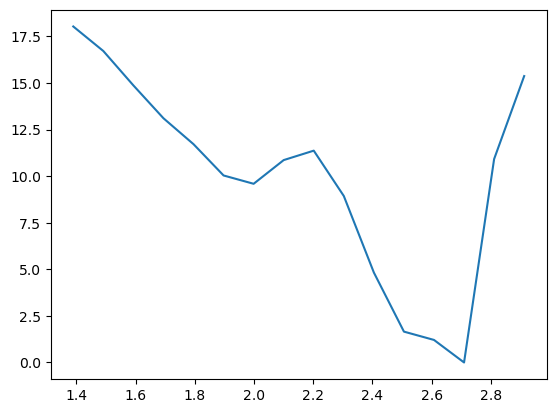

In [15]:
fes_E = np.loadtxt('../../Data/protG/PMF/pmf_E.dat')
xi = 10
xf = 26
plt.plot(fes_E[xi:xf,0],(fes_E[xi:xf,1]-np.min(fes_E[xi:xf,1])))

barr4: ln <e^βV> = 1.5582843887160676
barr5: ln <e^βV> = 1.927220728471339
barr6: ln <e^βV> = 2.2847792028988647
barr7: ln <e^βV> = 2.62910873290402
barr8: ln <e^βV> = 2.958300135204769
barr10: ln <e^βV> = 3.564105712471323


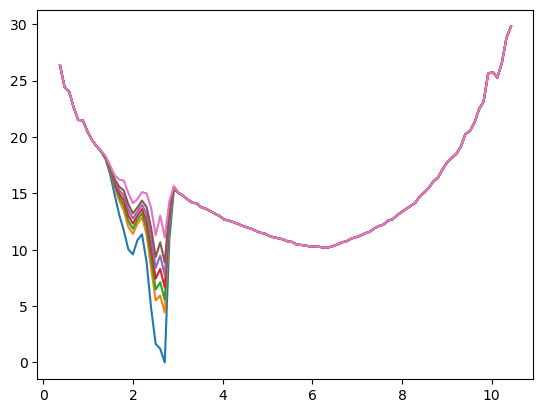

In [16]:
fes_E = np.loadtxt('../../Data/protG/PMF/pmf_E.dat')
plt.plot(fes_E[:,0],(fes_E[:,1]-np.min(fes_E[:,1])))

barrs = [4,5,6,7,8,10]
gaussian = lambda x, H: H*(0.9*np.exp(-((x-2.45)**2)/(0.2**2))+np.exp(-((x-2.68)**2)/(0.12**2))+0.5*np.exp(-((x-1.9)**2)/(0.3**2)))
gaussianE = lambda x, H: H*(0.9*np.exp(-((x-2.45)**2)/(0.2**2))+np.exp(-((x-2.68)**2)/(0.12**2))+0.5*np.exp(-((x-1.9)**2)/(0.3**2)))
for barr in barrs:
    print(f'barr{barr}: ln <e^βV> = {np.log( np.average(np.exp(beta*gaussian(fes_E[10:26,0],barr)),weights=np.exp(-beta*(gaussian(fes_E[10:26,0],barr)+(fes_E[10:26,1]-np.min(fes_E[10:26,1]))))) )}')
    plt.plot(fes_E[:,0], (fes_E[:,1]-np.min(fes_E[:,1]))+gaussian(fes_E[:,0],barr))

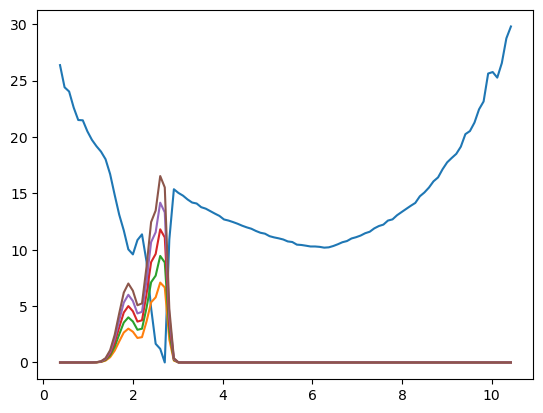

In [17]:
fes_E = np.loadtxt('../../Data/protG/PMF/pmf_E.dat')
plt.plot(fes_E[:,0],(fes_E[:,1]-np.min(fes_E[:,1])))

barrs = [6,8,10,12,14]
gaussian = lambda x, H: H*(0.9*np.exp(-((x-2.45)**2)/(0.2**2))+np.exp(-((x-2.68)**2)/(0.12**2))+0.5*np.exp(-((x-1.9)**2)/(0.3**2)))
for barr in barrs:
    plt.plot(fes_E[:,0], gaussian(fes_E[:,0],barr))

In [18]:
k0s_e = {}
k0s_e2 = {}
v_datas_e = {}
avg_ebv_e = []
ana_avg_ebv_e = []
avg_ebv_t_e = {}

gammas = np.linspace(0,1,21)
barrs = ['4','5','6','7','8','10']

ts_barrs = []
ix_col_barrs_e = []
ys_barrs = []
emp_rates_e = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}

def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_e[barr] = []
    k0s_e2[barr] = []
    
    colvars = glob(f"../../Data/protG/E_end_end_distance_gaussian/eruns_{barr}kJ/*/bias.colvar")
    log_files = glob(f"../../Data/protG/E_end_end_distance_gaussian/eruns_{barr}kJ/*/p.log")
    data = RM.get_data(colvars,0,1,time_scale_factor=1e-6)
    num_runs = len(data)
    colvars_numbers = np.array([colvar.split('/')[-2].split('_')[-1] for colvar in colvars])
    logs_numbers = np.array([log_file.split('/')[-2].split('_')[-1] for log_file in log_files])
    #for i, traj in enumerate(data):
    #    if (len(traj) < 199999):
    #        print(i+1, len(traj))
    
    runs = [f"{i+1}" for i in range(num_runs)]

    # Handle transitions and killed simulations
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    event_notend = RM.get_event(data, maxlen=100000, quiet=True)
    killed = np.logical_xor(transitioned, event_notend)
    nontransition = np.logical_not(event_notend)
    #print(f'transitioned: {colvars_numbers[np.nonzero(transitioned)[0]]}')
    #print(f'killed: {colvars_numbers[np.nonzero(killed)[0]]}')
    #print(f'ended: {colvars_numbers[np.nonzero(nontransition)[0]]}')
    final_times = np.array([traj[-1][0] for traj in data])
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]+np.float64(barr)))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_maxrow_count = max(len(traj[:,0]) for traj in data)
    v_data = np.full((len(data), colvar_maxrow_count), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:len(traj)] = traj[:,1]+np.float64(barr)
    v_datas_e[barr] = v_data
    
    ecdfxs[barr] = np.sort(final_times)[:transitioned.sum()] # This is only valid if all transitions occur before all non-transitioned simulations ended.
    ecdfys[barr] = np.linspace(1/num_runs,1,num_runs)[:transitioned.sum()]
    emp_rate = optimize.curve_fit(poisson_CDF,ecdfxs[barr],ecdfys[barr],p0=1e-6)[0][0]
    emp_rates_e[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')

    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    ecdfxs[barr] = t
    ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_e[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln <e^βV>: {np.log(avg)}')
    print(f'Analytical ln <e^βV>: {np.log( np.average(np.exp(beta*gaussianE(fes_E[10:26,0],np.float64(barr))),weights=np.exp(-beta*(gaussianE(fes_E[10:26,0],np.float64(barr))+(fes_E[10:26,1]-np.min(fes_E[10:26,1]))))) )}')
    avg_ebv_e.append(np.log(avg))
    ana_avg_ebv_e.append(np.log( np.average(np.exp(beta*gaussianE(fes_E[10:26,0],np.float64(barr))),weights=np.exp(-beta*(gaussianE(fes_E[10:26,0],np.float64(barr))+(fes_E[10:26,1]-np.min(fes_E[10:26,1]))))) ))
    
    print('')
    
    for gamma in gammas:
        #avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=1))
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=0))
        avg2 = np.average(np.exp(beta*gamma*gaussianE(fes_E[10:26,0],np.float64(barr))),weights=np.exp(-beta*(gaussianE(fes_E[10:26,0],np.float64(barr))+(fes_E[10:26,1]-np.min(fes_E[10:26,1])))))
        k0s_e[barr].append(np.log(emp_rate)-np.log(avg))
        k0s_e2[barr].append(np.log(emp_rate)-np.log(avg2))
        
        #print(gamma)

100 out of 100 simulations transitioned.
avg. max. bias: 4.996308
tau_obs: 0.40930631858657823, k_obs: 2.4431579836177773, log k_obs: 0.8932914580593796
Modified KS stat: 0.8494135482043434; p = 0.4662105903208519
ln <e^βV>: 1.8811650644127946
Analytical ln <e^βV>: 1.5582843887160676

100 out of 100 simulations transitioned.
avg. max. bias: 5.996308
tau_obs: 0.3710842821824434, k_obs: 2.6948055954262986, log k_obs: 0.991326066481275
Modified KS stat: 0.8518450491169414; p = 0.462520535540655
ln <e^βV>: 2.266658478760942
Analytical ln <e^βV>: 1.927220728471339

100 out of 100 simulations transitioned.
avg. max. bias: 6.996308
tau_obs: 0.3467370999989211, k_obs: 2.8840294274916403, log k_obs: 1.0591884230778714
Modified KS stat: 0.42730350393702143; p = 0.9931775400180494
ln <e^βV>: 2.6510633745727508
Analytical ln <e^βV>: 2.2847792028988647

100 out of 100 simulations transitioned.
avg. max. bias: 7.996308
tau_obs: 0.2769624362971579, k_obs: 3.6105979329524756, log k_obs: 1.283873391026

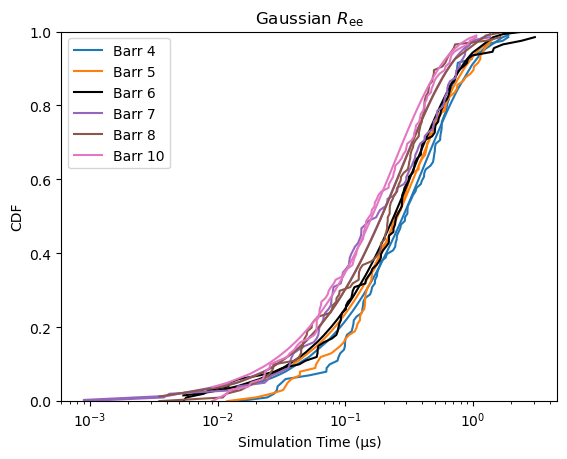

In [19]:
plt.xscale('log')
plt.ylim((0,1))

colors = ['C0','C1','k','C4','C5','C6','C7','C8','C9','C10']

for i, barr in enumerate(barrs):
    plt.plot(ecdfxs[barr],ecdfys[barr],label=f'Barr {barr}',color=colors[i])
    plt.plot(ecdfxs[barr],poisson_CDF(ecdfxs[barr],emp_rates_e[barr]),color=colors[i])

plt.title(r'Gaussian $R_\mathrm{ee}$')
plt.xlabel('Simulation Time (μs)')
plt.ylabel('CDF')
plt.legend()

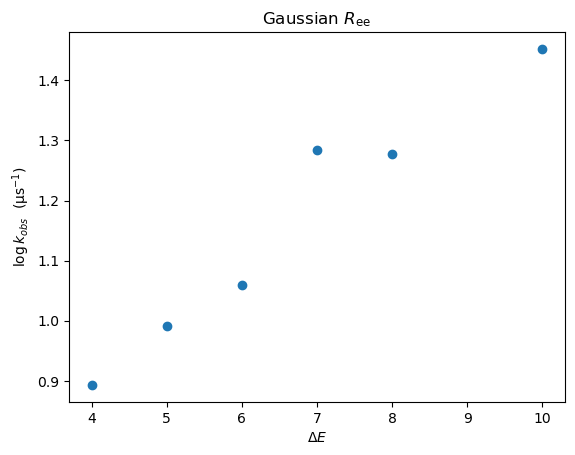

In [20]:
plt.title(r'Gaussian $R_\mathrm{ee}$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{μs}^{-1})$')
plt.xlabel(r'$\Delta E$')
plt.scatter([float(barr) for barr in barrs],[k0s_e[barr][0] for barr in barrs])

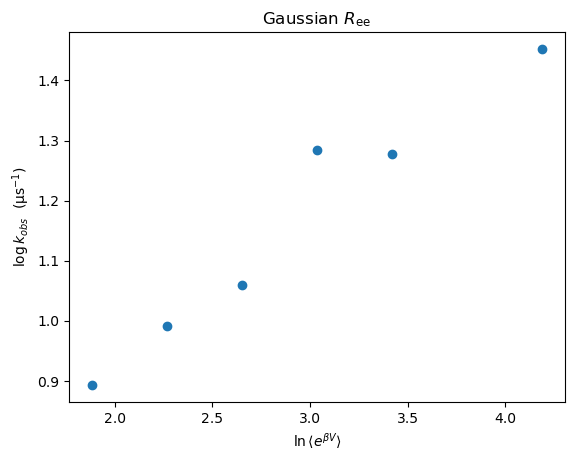

In [21]:
plt.title(r'Gaussian $R_\mathrm{ee}$')
plt.xlabel(r'$\ln \langle e^{\beta V} \rangle$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{μs}^{-1})$')
plt.scatter(avg_ebv_e,[k0s_e[barr][0] for barr in barrs])

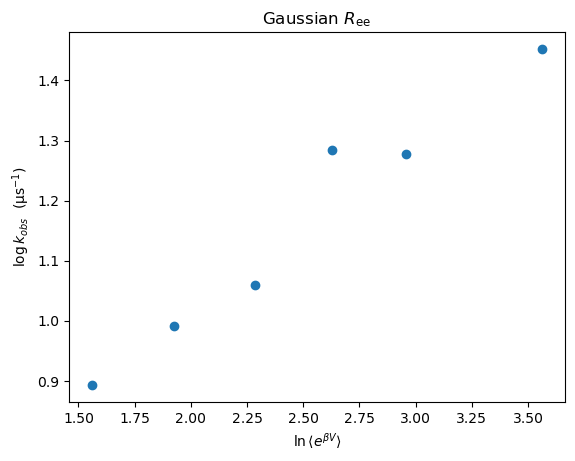

In [22]:
plt.title(r'Gaussian $R_\mathrm{ee}$')
plt.xlabel(r'$\ln \langle e^{\beta V} \rangle$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{μs}^{-1})$')
plt.scatter(ana_avg_ebv_e,[k0s_e2[barr][0] for barr in barrs])

Text(0, 0.5, '$\\ln k_0~~(\\mathrm{μs}^{-1})$')

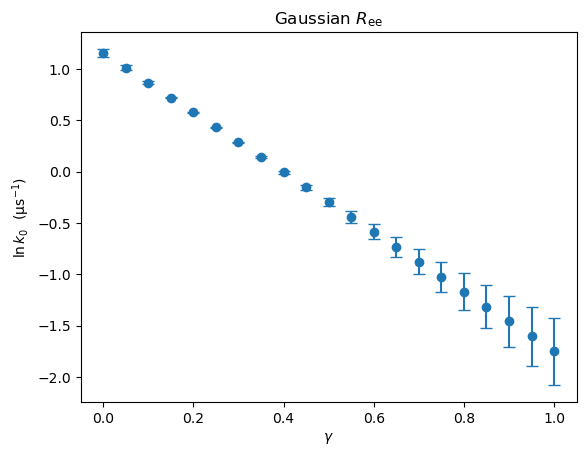

In [23]:
avgs_e = [np.mean([k0s_e[barr][i] for barr in barrs]) for i in range(len(gammas))]
vars_e = [np.var([k0s_e[barr][i] for barr in barrs]) for i in range(len(gammas))]

plt.errorbar(gammas,avgs_e,yerr=vars_e,linestyle='',marker='o',capsize=4)
#plt.axhline(np.log(true),linestyle='--',color='k',label=r'$\ln k_0$')
plt.title(r'Gaussian $R_\mathrm{ee}$')
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\ln k_0~~(\mathrm{μs}^{-1})$')

Text(0, 0.5, 'Variance')

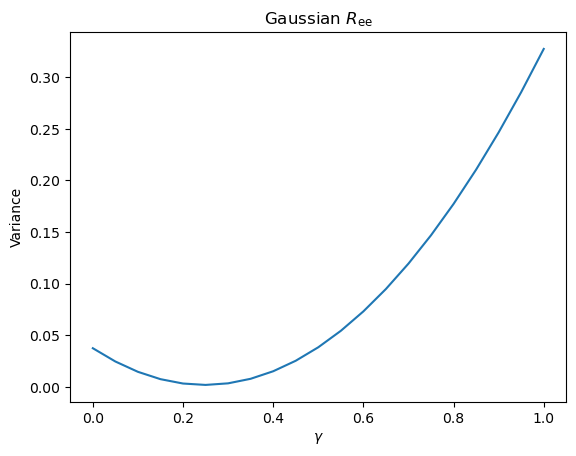

In [24]:
plt.plot(gammas,vars_e)
plt.title(r'Gaussian $R_\mathrm{ee}$')
plt.xlabel(r'$\gamma$')
plt.ylabel('Variance')

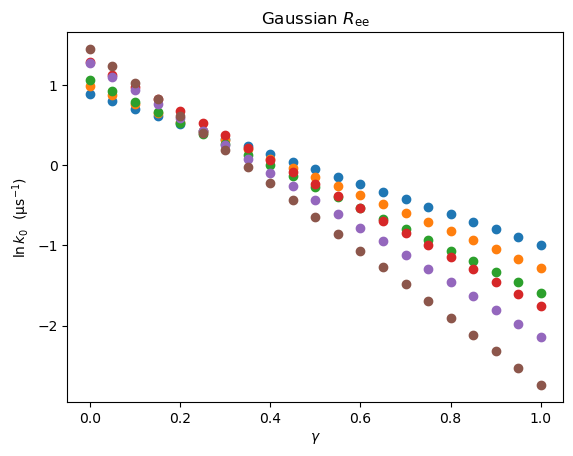

In [28]:
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\ln k_0~~(\mathrm{μs}^{-1})$')
plt.title(r'Gaussian $R_\mathrm{ee}$')

for barr in barrs:
    plt.scatter(gammas,k0s_e[barr])


In [25]:
def variance(gamma):
    k0s = []
    for barr in barrs:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_datas_e[barr]),axis=0))
        k0s.append(np.log(emp_rates_e[barr])-np.log(avg))
    return np.var(k0s)

gamma_best_e = optimize.minimize_scalar(variance,bounds=(0.,1.)).x
k0s = []
for barr in barrs:
    avg = np.mean(np.nanmean(np.exp(beta*gamma_best_e*v_datas_e[barr]),axis=0))
    k0s.append(np.log(emp_rates_e[barr])-np.log(avg))
k0_best_e = np.mean(k0s)
print(f'LEAST VAR:  gamma: {gamma_best_e}, k0: {np.exp(k0_best_e)} μs^-1, τ0: {np.exp(-k0_best_e)} μs')

LEAST VAR:  gamma: 0.24842402662166646, k0: 1.548211902189054 μs^-1, τ0: 0.6459064153854366 μs


In [26]:
def variance(gamma):
    k0s = []
    for barr in barrs:
        avg = np.average(np.exp(beta*gamma*gaussianE(fes_E[10:26,0],np.float64(barr))),weights=np.exp(-beta*(gaussianE(fes_E[10:26,0],np.float64(barr))+(fes_E[10:26,1]-np.min(fes_E[10:26,1])))))
        k0s.append(np.log(emp_rates_e[barr])-np.log(avg))
    return np.var(k0s)

gamma_best_e2 = optimize.minimize_scalar(variance,bounds=(0.,1.)).x
k0s = []
for barr in barrs:
    avg = np.average(np.exp(beta*gamma_best_e2*gaussianE(fes_E[10:26,0],np.float64(barr))),weights=np.exp(-beta*(gaussianE(fes_E[10:26,0],np.float64(barr))+(fes_E[10:26,1]-np.min(fes_E[10:26,1])))))
    k0s.append(np.log(emp_rates_e[barr])-np.log(avg))
k0_best_e2 = np.mean(k0s)
print(f'LEAST VAR:  gamma: {gamma_best_e2}, k0: {np.exp(k0_best_e2)} μs^-1, τ0: {np.exp(-k0_best_e2)} μs')

LEAST VAR:  gamma: 0.3494185321278914, k0: 1.4160239854538328 μs^-1, τ0: 0.7062027269824119 μs


In [29]:
from matplotlib import gridspec

true = 0.35967608559103206
k_low = 0.2219796815459443 # np.log(true) - 0.06748333798671914
k_high = 0.46802748239726666 # np.log(true) + 0.06748333798671914

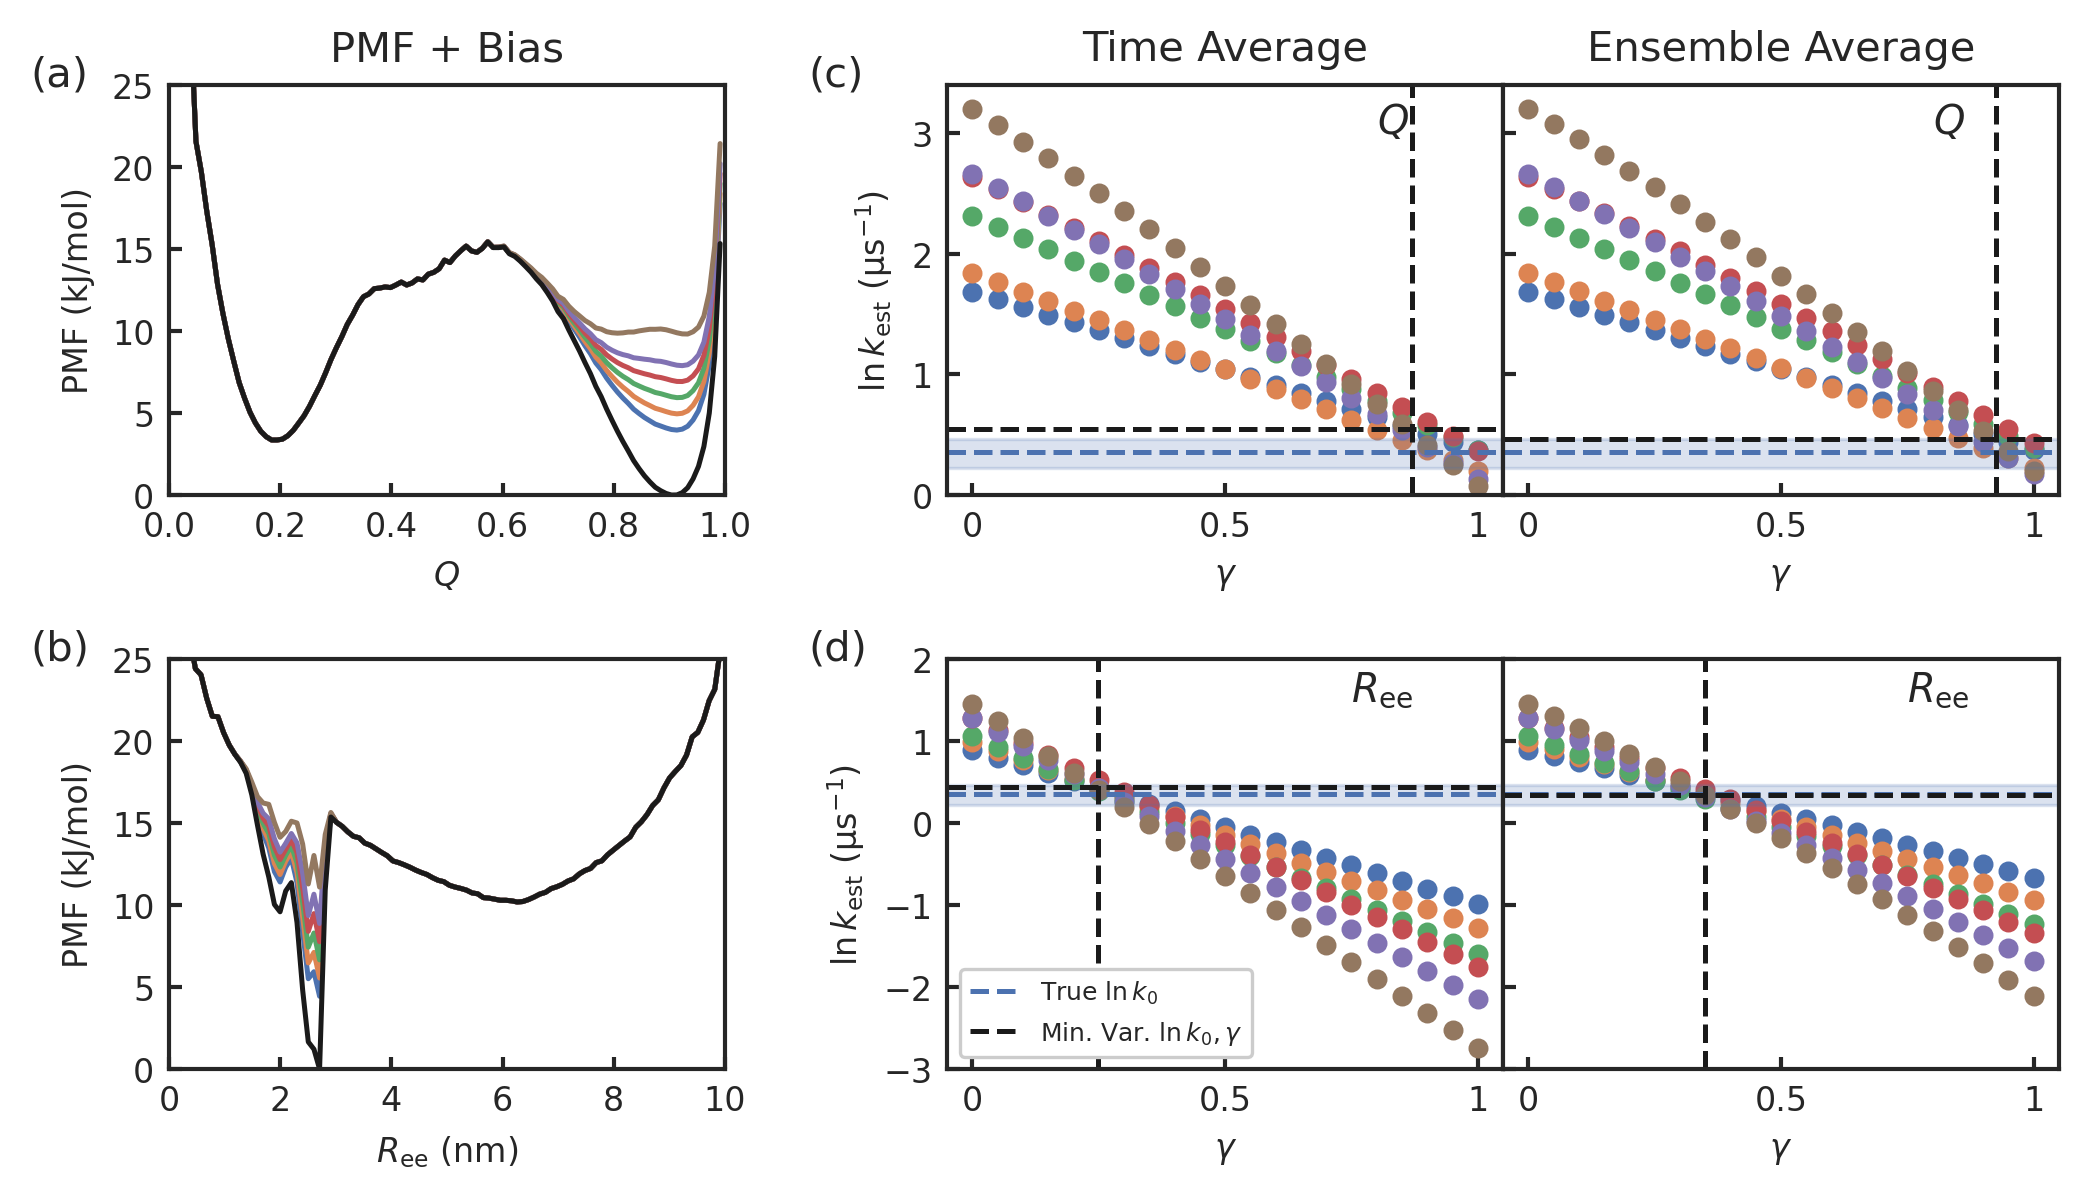

In [30]:
sns.set_theme()
sns.set_style('ticks')
sns.set_context('paper', rc={'axes.labelsize': 8, 'axes.linewidth': 1.0, 'lines.linewidth': 1.2, 'axes.titlesize': 10,
                             'xtick.labelsize': 8, 'ytick.labelsize': 8, 'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
                             'legend.fontsize': 6, 'legend.framealpha': 0, 'lines.markersize': 4})

gs = dict(wspace=0.0, width_ratios=[1, 0.4, 1, 1])

fig, axs = plt.subplots(2,4,figsize=(7,4),dpi=300,sharey=False,sharex=False,gridspec_kw=gs)
fig.subplots_adjust(hspace=0.4,bottom=0.1,left=0.08,right=0.98,top=0.92)

axs[0,0].set_title('PMF + Bias')

axs[0,0].text(-0.25,1.0,"(a)",fontsize=10,transform=axs[0,0].transAxes)
axs[0,0].set_xlabel(r'$Q$')
axs[0,0].set_ylabel(r'PMF (kJ/mol)')
axs[0,0].set_ylim((0,25))
axs[0,0].set_xlim((0,1))
for barr in barrs:
    axs[0,0].plot(fes_Q[:,0], (fes_Q[:,1]-np.min(fes_Q[:,1]))+gaussianQ(fes_Q[:,0],np.float64(barr)))
axs[0,0].plot(fes_Q[:,0],(fes_Q[:,1]-np.min(fes_Q[:,1])),color='k')
#axs[0,0].text(0.75,22,r'$Q$')

axs[1,0].text(-0.25,1.0,"(b)",fontsize=10,transform=axs[1,0].transAxes)
axs[1,0].set_xlabel(r'$R_\mathrm{ee}~(\mathrm{nm})$')
axs[1,0].set_ylabel(r'PMF (kJ/mol)')
axs[1,0].set_ylim((0,25))
axs[1,0].set_xlim((0,10))
for barr in barrs:
    axs[1,0].plot(fes_E[:,0], (fes_E[:,1]-np.min(fes_E[:,1]))+gaussianE(fes_E[:,0],np.float64(barr)))
axs[1,0].plot(fes_E[:,0],(fes_E[:,1]-np.min(fes_E[:,1])),color='k')
#axs[1,0].text(7,22,r'$R_\mathrm{ee}$')

axs[0,1].set_visible(False)
axs[1,1].set_visible(False)


axs[0,2].set_title('Time Average')

axs[0,2].text(-0.25,1.0,"(c)",fontsize=10,transform=axs[0,2].transAxes)
axs[0,2].set_xlabel(r'$\gamma$')
axs[0,2].set_ylabel(r'$\ln k_\mathrm{est}~(\mathrm{\mu s}^{-1})$')
axs[0,2].set_xlim((-0.05,1.05))
axs[0,2].set_ylim((0,3.4))
axs[0,2].set_xticks([0,0.5,1],labels=[0,0.5,1])
axs[0,2].text(0.8,3,r'$Q$')
for barr in barrs:
    axs[0,2].scatter(gammas,k0s_q[barr])
axs[0,2].axhline(true,linestyle='--',color='C0')
axs[0,2].fill_between([-0.05,1.05],k_low,k_high,alpha=0.2,color='C0')
axs[0,2].axhline(k0_best_q,linestyle='--',color='k')
axs[0,2].axvline(gamma_best_q,linestyle='--',color='k')

axs[1,2].text(-0.25,1.0,"(d)",fontsize=10,transform=axs[1,2].transAxes)
axs[1,2].set_xlabel(r'$\gamma$')
axs[1,2].set_ylabel(r'$\ln k_\mathrm{est}~(\mathrm{\mu s}^{-1})$')
axs[1,2].set_xlim((-0.05,1.05))
axs[1,2].set_ylim((-3,2))
axs[1,2].set_xticks([0,0.5,1],labels=[0,0.5,1])
axs[1,2].text(0.75,1.5,r'$R_\mathrm{ee}$')
for barr in barrs:
    axs[1,2].scatter(gammas,k0s_e[barr])
axs[1,2].axhline(true,linestyle='--',color='C0',label=r'True $\ln k_0$')
axs[1,2].fill_between([-0.05,1.05],k_low,k_high,alpha=0.2,color='C0')
axs[1,2].axhline(k0_best_e,linestyle='--',color='k',label=r'Min. Var. $\ln k_0,\gamma$')
axs[1,2].axvline(gamma_best_e,linestyle='--',color='k')
axs[1,2].legend(loc='lower left',framealpha=1)


axs[0,3].set_title('Ensemble Average')

axs[0,3].set_xlabel(r'$\gamma$')
axs[0,3].set_xlim((-0.05,1.05))
axs[0,3].set_ylim((0,3.4))
axs[0,3].set_xticks([0,0.5,1],labels=[0,0.5,1])
axs[0,3].set_yticks([0,1,2,3],labels=[])
axs[0,3].text(0.8,3,r'$Q$')
for barr in barrs:
    axs[0,3].scatter(gammas,k0s_q2[barr])
axs[0,3].axhline(true,linestyle='--',color='C0')
axs[0,3].fill_between([-0.05,1.05],k_low,k_high,alpha=0.2,color='C0')
axs[0,3].axhline(k0_best_q2,linestyle='--',color='k')
axs[0,3].axvline(gamma_best_q2,linestyle='--',color='k')

axs[1,3].set_xlabel(r'$\gamma$')
axs[1,3].set_xlim((-0.05,1.05))
axs[1,3].set_ylim((-3,2))
axs[1,3].set_xticks([0,0.5,1],labels=[0,0.5,1])
axs[1,3].set_yticks([-3,-2,-1,0,1,2],labels=[])
axs[1,3].text(0.75,1.5,r'$R_\mathrm{ee}$')
for barr in barrs:
    axs[1,3].scatter(gammas,k0s_e2[barr])
axs[1,3].axhline(true,linestyle='--',color='C0')
axs[1,3].fill_between([-0.05,1.05],k_low,k_high,alpha=0.2,color='C0')
axs[1,3].axhline(k0_best_e2,linestyle='--',color='k')
axs[1,3].axvline(gamma_best_e2,linestyle='--',color='k')


for ax in axs.flatten():
    ax.tick_params(axis='both', direction='in', which='both', length=3)
    
plt.savefig("EATRf_FigS3.pdf",format='pdf')